# Experiment on Self-collected (HousePlans.net) 50 images


### **1. Install and import necessary libraries**

In [1]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 42.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="g5SoZrd0K4IS1LKVI4iw")
project = rf.workspace("pygoh-yazcv").project("floor-plan-v3")
version = project.version(13)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Floor-Plan-V3-13 in yolov11:: 100%|██████████| 254/254 [00:00<00:00, 4923.80it/s]


In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
import numpy as np
import cv2, os, json

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### **2. Train Yolo11 segmentation model**

In [ ]:
model = YOLO("yolo11s-seg.pt")  # load a pretrained model

results = model.train(
    data="/content/Floor-Plan-V3-13/data.yaml", 
    epochs=300,
    imgsz=1024,
    batch=8,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=10,
    momentum=0.9,
    weight_decay=0.0001,
    patience=40,
    cls=2.0
    )

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Floor-Plan-V3-13/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=40, p

### **3. Training Evaluation Metrices Graph & Confusion Matrix**

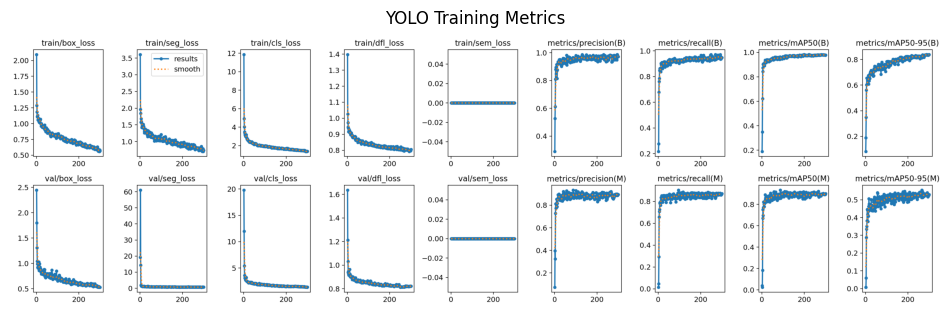

In [5]:
# Path to your training results image
results_path = "/content/runs/segment/train/results.png"

# Load and visualize
results_img = Image.open(results_path)

plt.figure(figsize=(12, 6))
plt.imshow(results_img)
plt.title("YOLO Training Metrics")
plt.axis("off")
plt.show()

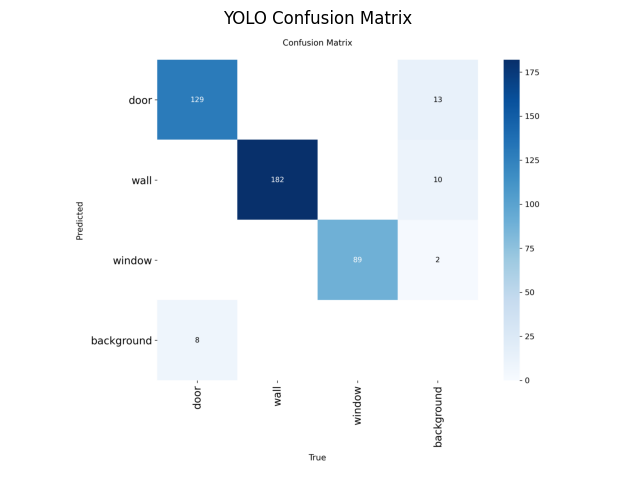

In [6]:
# Path to your confusion matrix image
confusion_path = "/content/runs/segment/train/confusion_matrix.png"

# Load and visualize
confusion_img = Image.open(confusion_path)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_img)
plt.title("YOLO Confusion Matrix")
plt.axis("off")
plt.show()

### **4. Calculate for Evaluation Metrics defined in Report Section 3.5.3**

In [1]:
import numpy as np
#Confusion matrix
cm = np.array([
     [129,   0,   0,  13],
     [  0, 182,   0,  10],
     [  0,   0,  89,   2],
     [ 8,   0,   0,   0]
])

#### Metrics: Accuracy=  N_ii/(∑_j(N_ij))

In [2]:
import numpy as np

def compute_per_class_accuracy(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    accuracies = {}
    acc_list = []

    for i in range(num_classes):
        # skip background (last index)
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        total_pred = cm[:, i].sum()

        if total_pred == 0:
            acc_i = 0.0
        else:
            acc_i = TP / total_pred

        accuracies[i] = acc_i
        acc_list.append(acc_i)

    mAcc = np.mean(acc_list) if acc_list else 0.0

    return accuracies, acc_list, mAcc

In [3]:
names = [
    'door',
    'wall',
    "window",
    'background'
]

acc_dict, _, mAcc = compute_per_class_accuracy(cm)

for i, acc in acc_dict.items():
    print(f"{names[i]}: {acc:.2f}")

print(f"\nMean Accuracy (mAcc): {mAcc:.2f}")

door: 0.94
wall: 1.00
window: 1.00

Mean Accuracy (mAcc): 0.98


#### Overall Accuracy= (∑_i^C(N_ii))/(∑_i^C(∑_j)(N_ij))

In [8]:
def compute_overall_accuracy_no_bg(cm):
    cm = np.array(cm)
    cm_fg = cm[:, :-1]

    correct = np.trace(cm_fg[:-1, :])
    total = cm_fg.sum()

    return correct / total

In [9]:
overall_acc = compute_overall_accuracy_no_bg(cm)
print(f"Overall Accuracy: {overall_acc:.2f}")

Overall Accuracy: 0.98


#### IoU= TP/((TP+FP+FN))

In [6]:
import numpy as np

def compute_per_class_iou(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    iou_dict = {}
    iou_list = []

    for i in range(num_classes):
        # skip background
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP

        IoU = TP / (TP + FP + FN)

        iou_dict[i] = IoU
        iou_list.append(IoU)

    mIoU = np.mean(iou_list)

    return iou_dict, iou_list, mIoU

In [7]:
iou_dict, _, mIoU = compute_per_class_iou(cm)

for i, iou in iou_dict.items():
    print(f"{names[i]}: {iou:.2f}")

print(f"\nMean IoU (mIoU): {mIoU:.2f}")

door: 0.86
wall: 0.95
window: 0.98

Mean IoU (mIoU): 0.93


#### Precision = TP/(TP + FP)

In [13]:
import numpy as np

def compute_per_class_precision(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    precision_dict = {}
    precision_list = []

    for i in range(num_classes):
        # skip background
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        FP = cm[i, :].sum() - TP

        precision = TP / (TP + FP)

        precision_dict[i] = precision
        precision_list.append(precision)

    mPrecision = np.mean(precision_list)

    return precision_dict, precision_list, mPrecision

In [14]:
precision_dict, _, mPrecision = compute_per_class_precision(cm)

for i, p in precision_dict.items():
    print(f"{names[i]}: {p:.2f}")

print(f"\nMean Precision: {mPrecision:.2f}")

door: 0.91
wall: 0.95
window: 0.98

Mean Precision: 0.94


#### Recall = TP/(TP + FN)

In [15]:
import numpy as np

def compute_per_class_recall(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    recall_dict = {}
    recall_list = []

    for i in range(num_classes):
        # skip background
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        FN = cm[:, i].sum() - TP

        recall = TP / (TP + FN)

        recall_dict[i] = recall
        recall_list.append(recall)

    mRecall = np.mean(recall_list)

    return recall_dict, recall_list, mRecall

In [16]:
recall_dict, _, mRecall = compute_per_class_recall(cm)

for i, r in recall_dict.items():
    print(f"{names[i]}: {r:.2f}")

print(f"\nMean Recall: {mRecall:.2f}")

door: 0.94
wall: 1.00
window: 1.00

Mean Recall: 0.98


#### F1-score=(2⋅Precision⋅Recall)/(Precision+Recall)

In [17]:
import numpy as np

def compute_per_class_f1(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    f1_dict = {}
    f1_list = []

    for i in range(num_classes):
        # skip background
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        FP = cm[i, :].sum() - TP
        FN = cm[:, i].sum() - TP

        precision = TP / (TP + FP)
        recall = TP / (TP + FN)

        f1 = 2 * precision * recall / (precision + recall)

        f1_dict[i] = f1
        f1_list.append(f1)

    mF1 = np.mean(f1_list)

    return f1_dict, f1_list, mF1

In [18]:
f1_dict, _, mF1 = compute_per_class_f1(cm)

for i, f in f1_dict.items():
    print(f"{names[i]}: {f:.2f}")

print(f"\nMean F1: {mF1:.2f}")

door: 0.92
wall: 0.97
window: 0.99

Mean F1: 0.96


### **5. Visualization of Results**

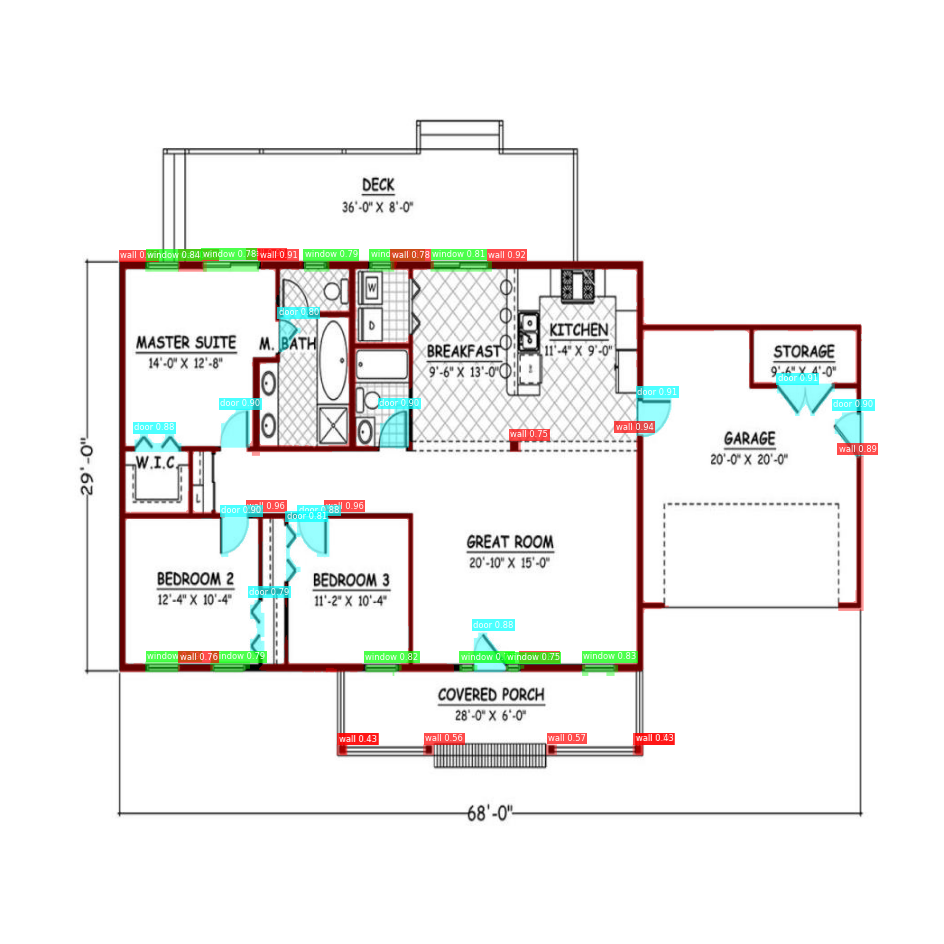

In [14]:
# Load your trained model
model = YOLO("/content/runs/segment/train/weights/best.pt")

# Run inference
img_path = "/content/Floor-Plan-V3-13/valid/images/18933-1-1200_page1_png.rf.2367e533b12a91f9cfa09a6df3cc97e2.jpg"
results = model.predict(source=img_path, imgsz=1024, conf=0.3, save=False, verbose=False)

# Load original image
img = np.array(Image.open(img_path).convert("RGB"))

# Prepare figure
plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")

# Get result
r = results[0]
names = model.names  # class names dict {id: name}

if r.masks:
    masks = r.masks.data.cpu().numpy()
    boxes = r.boxes.xyxy.cpu().numpy()
    cls_ids = r.boxes.cls.cpu().numpy().astype(int)
    scores = r.boxes.conf.cpu().numpy()

    # --- Custom distinct colors per class ---
    custom_colors = [
        (0.0, 1.0, 1.0),  # cyan
        (1.0, 0.0, 0.0),  # red
        (0.0, 1.0, 0.0),  # green
    ]
    def get_color(cls_id):
        return custom_colors[cls_id % len(custom_colors)]

    # --- Draw masks with transparency and consistent color per class ---
    for i, mask in enumerate(masks):
        cls_id = cls_ids[i]
        conf = scores[i]
        color = get_color(cls_id)

        # Create RGBA overlay
        colored_mask = np.zeros((*mask.shape, 4))
        colored_mask[..., :3] = color
        colored_mask[..., 3] = mask * 0.4  # transparency
        plt.imshow(colored_mask)

        # Draw label text
        x1, y1, x2, y2 = boxes[i]
        label = f"{names[cls_id]} {conf:.2f}"
        plt.text(
            x1, y1 - 5, label,
            color='white',
            fontsize=6,
            bbox=dict(facecolor=color, alpha=0.7, edgecolor='none', pad=1)
        )

plt.show()

### **6. Annotations VS Predicted Mask Visualization**

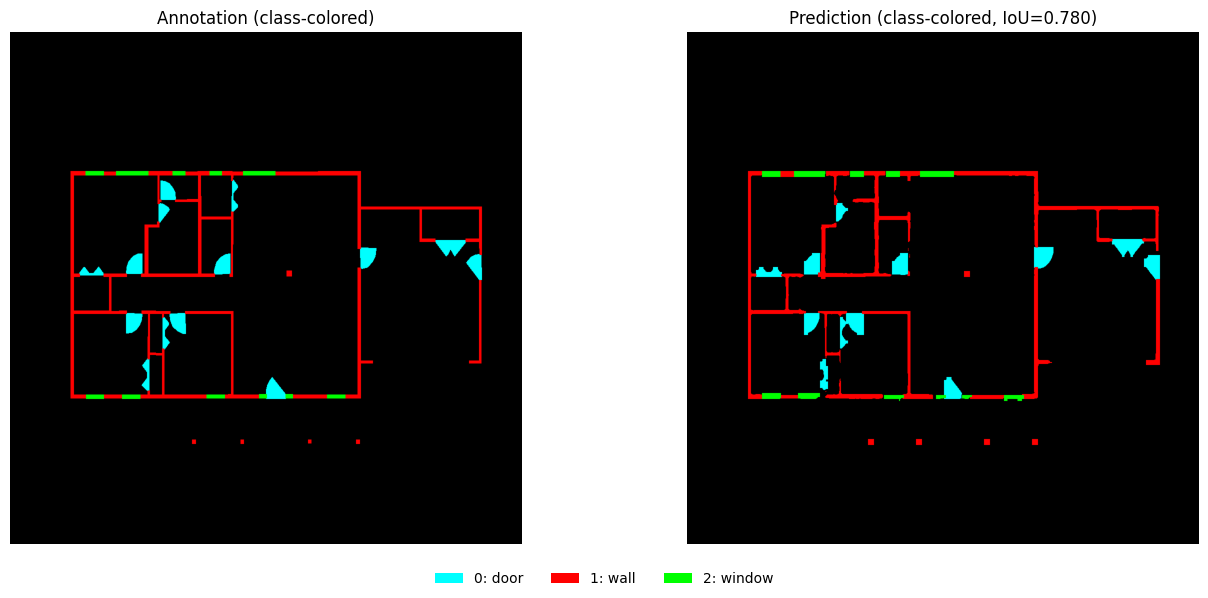

Per-class IoU:
   0         door: 0.742
   1         wall: 0.791
   2       window: 0.685


In [15]:
# ---- paths & model ----
model = YOLO("/content/runs/segment/train/weights/best.pt")
img_path = "/content/Floor-Plan-V3-13/valid/images/18933-1-1200_page1_png.rf.2367e533b12a91f9cfa09a6df3cc97e2.jpg"
label_path = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"

# ---- custom, distinct RGB colors (extend/modify as you like) ----
CUSTOM_COLORS = [
    (0, 255, 255),  # cyan
    (255, 0, 0),    # red
    (0, 255, 0),    # green
]
def color_for(cid):  # handles more classes than colors by cycling
    return np.array(CUSTOM_COLORS[cid % len(CUSTOM_COLORS)], dtype=np.uint8)

# ---- inference ----
res = model.predict(source=img_path, imgsz=1024, conf=0.25, save=False, verbose=False)[0]
H, W = res.orig_shape
names = model.names
num_classes = len(names)

# ---- annotation masks from YOLO polygon labels -> per-class binary masks ----
ann_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 2:
                cid = int(parts[0])
                xy = np.array(parts[1:], dtype=float).reshape(-1, 2)
                pts = np.column_stack((xy[:, 0] * W, xy[:, 1] * H)).astype(np.int32)
                cv2.fillPoly(ann_per_class[cid], [pts], 1)

# ---- prediction masks -> per-class binary masks (union over instances) ----
pred_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if res.masks:
    pmasks = (res.masks.data.cpu().numpy() > 0.5)  # (N,H,W)
    cls_ids = res.boxes.cls.cpu().numpy().astype(int)
    for m, cid in zip(pmasks, cls_ids):
        pred_per_class[cid] |= m.astype(np.uint8)

# ---- colored canvases (annotation & prediction) using custom palette ----
ann_rgb  = np.zeros((H, W, 3), dtype=np.uint8)
pred_rgb = np.zeros((H, W, 3), dtype=np.uint8)
for cid in range(num_classes):
    col = color_for(cid)
    ann_rgb[ann_per_class[cid] == 1]  = col
    pred_rgb[pred_per_class[cid] == 1] = col

# ---- compute IoU metrics ----
ann_any  = (ann_per_class.sum(axis=0)  > 0)
pred_any = (pred_per_class.sum(axis=0) > 0)
intersection = ann_any & pred_any
union = ann_any | pred_any
iou_overall = (intersection.sum() / union.sum()) if union.any() else 0.0

# per-class IoU
ious = []
for cid in range(num_classes):
    inter_c = np.logical_and(ann_per_class[cid], pred_per_class[cid]).sum()
    union_c = np.logical_or(ann_per_class[cid], pred_per_class[cid]).sum()
    ious.append(inter_c / union_c if union_c > 0 else np.nan)

# ---- legend for classes ----
legend_patches = []
for cid in range(num_classes):
    col = color_for(cid) / 255.0
    legend_patches.append(Patch(facecolor=col, edgecolor='none', label=f"{cid}: {names.get(cid, str(cid))}"))

# ---- plot (2 columns: annotation and prediction) ----
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(ann_rgb)
ax[0].set_title("Annotation (class-colored)")
ax[0].axis("off")

ax[1].imshow(pred_rgb)
ax[1].set_title(f"Prediction (class-colored, IoU={iou_overall:.3f})")
ax[1].axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=min(num_classes, 6), frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# ---- print per-class IoU table ----
print("Per-class IoU:")
for cid, iou_c in enumerate(ious):
    label = names.get(cid, str(cid))
    val = "n/a" if np.isnan(iou_c) else f"{iou_c:.3f}"
    print(f"  {cid:2d} {label:>12s}: {val}")

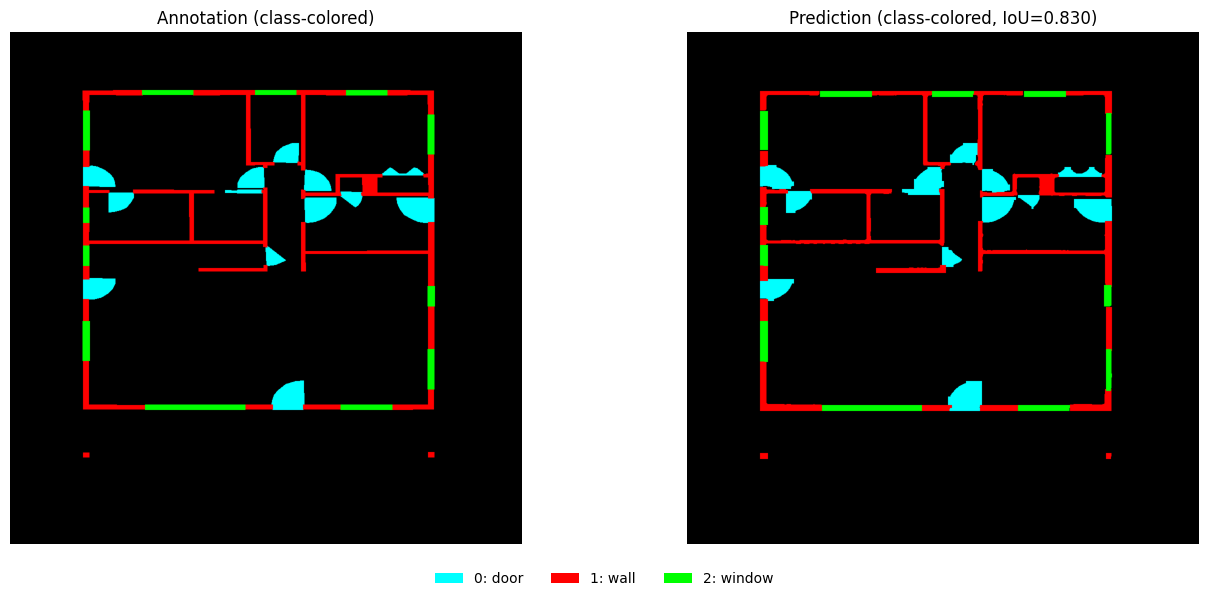

Per-class IoU:
   0         door: 0.862
   1         wall: 0.819
   2       window: 0.728


In [17]:
# ---- paths & model ----
model = YOLO("/content/runs/segment/train/weights/best.pt")
img_path = "/content/Floor-Plan-V3-13/valid/images/20444-1-1200_page1_png.rf.9131c7be150c28d60c1d22b620f4efbb.jpg"
label_path = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"

# ---- custom, distinct RGB colors (extend/modify as you like) ----
CUSTOM_COLORS = [
    (0, 255, 255),  # cyan
    (255, 0, 0),    # red
    (0, 255, 0),    # green
]
def color_for(cid):  # handles more classes than colors by cycling
    return np.array(CUSTOM_COLORS[cid % len(CUSTOM_COLORS)], dtype=np.uint8)

# ---- inference ----
res = model.predict(source=img_path, imgsz=1024, conf=0.25, save=False, verbose=False)[0]
H, W = res.orig_shape
names = model.names
num_classes = len(names)

# ---- annotation masks from YOLO polygon labels -> per-class binary masks ----
ann_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 2:
                cid = int(parts[0])
                xy = np.array(parts[1:], dtype=float).reshape(-1, 2)
                pts = np.column_stack((xy[:, 0] * W, xy[:, 1] * H)).astype(np.int32)
                cv2.fillPoly(ann_per_class[cid], [pts], 1)

# ---- prediction masks -> per-class binary masks (union over instances) ----
pred_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if res.masks:
    pmasks = (res.masks.data.cpu().numpy() > 0.5)  # (N,H,W)
    cls_ids = res.boxes.cls.cpu().numpy().astype(int)
    for m, cid in zip(pmasks, cls_ids):
        pred_per_class[cid] |= m.astype(np.uint8)

# ---- colored canvases (annotation & prediction) using custom palette ----
ann_rgb  = np.zeros((H, W, 3), dtype=np.uint8)
pred_rgb = np.zeros((H, W, 3), dtype=np.uint8)
for cid in range(num_classes):
    col = color_for(cid)
    ann_rgb[ann_per_class[cid] == 1]  = col
    pred_rgb[pred_per_class[cid] == 1] = col

# ---- compute IoU metrics ----
ann_any  = (ann_per_class.sum(axis=0)  > 0)
pred_any = (pred_per_class.sum(axis=0) > 0)
intersection = ann_any & pred_any
union = ann_any | pred_any
iou_overall = (intersection.sum() / union.sum()) if union.any() else 0.0

# per-class IoU
ious = []
for cid in range(num_classes):
    inter_c = np.logical_and(ann_per_class[cid], pred_per_class[cid]).sum()
    union_c = np.logical_or(ann_per_class[cid], pred_per_class[cid]).sum()
    ious.append(inter_c / union_c if union_c > 0 else np.nan)

# ---- legend for classes ----
legend_patches = []
for cid in range(num_classes):
    col = color_for(cid) / 255.0
    legend_patches.append(Patch(facecolor=col, edgecolor='none', label=f"{cid}: {names.get(cid, str(cid))}"))

# ---- plot (2 columns: annotation and prediction) ----
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(ann_rgb)
ax[0].set_title("Annotation (class-colored)")
ax[0].axis("off")

ax[1].imshow(pred_rgb)
ax[1].set_title(f"Prediction (class-colored, IoU={iou_overall:.3f})")
ax[1].axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=min(num_classes, 6), frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# ---- print per-class IoU table ----
print("Per-class IoU:")
for cid, iou_c in enumerate(ious):
    label = names.get(cid, str(cid))
    val = "n/a" if np.isnan(iou_c) else f"{iou_c:.3f}"
    print(f"  {cid:2d} {label:>12s}: {val}")

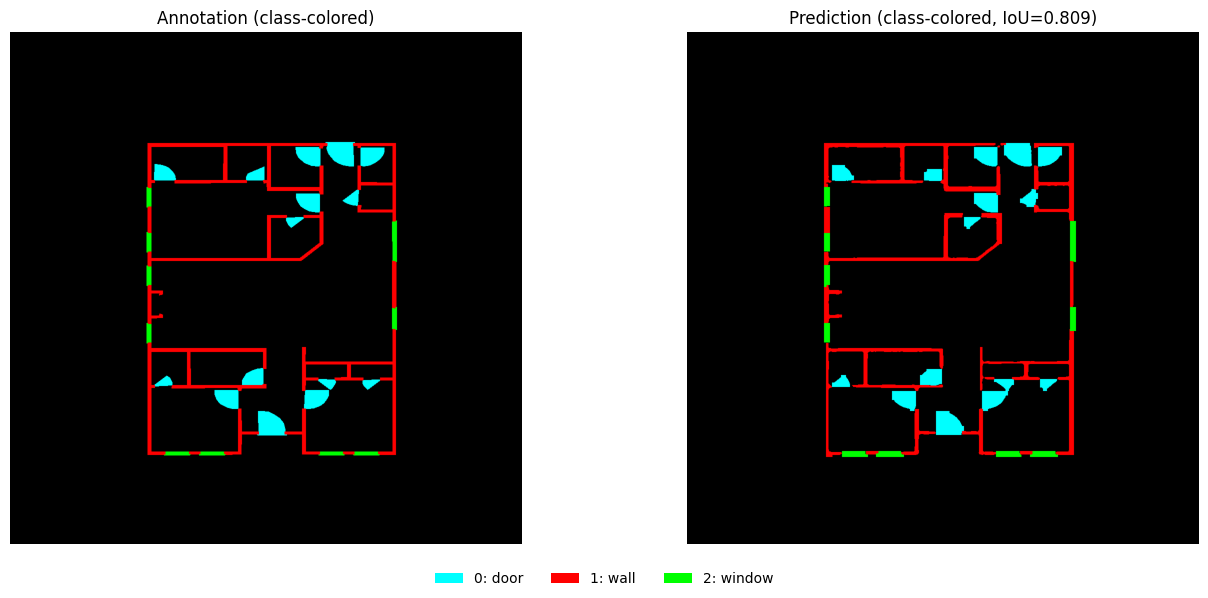

Per-class IoU:
   0         door: 0.872
   1         wall: 0.790
   2       window: 0.616


In [18]:
# ---- paths & model ----
model = YOLO("/content/runs/segment/train/weights/best.pt")
img_path = "/content/Floor-Plan-V3-13/valid/images/28636-1-1200_page1_png.rf.5d7367f8a741a5288ba34f4ddc091883.jpg"
label_path = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"

# ---- custom, distinct RGB colors (extend/modify as you like) ----
CUSTOM_COLORS = [
    (0, 255, 255),  # cyan
    (255, 0, 0),    # red
    (0, 255, 0),    # green
]
def color_for(cid):  # handles more classes than colors by cycling
    return np.array(CUSTOM_COLORS[cid % len(CUSTOM_COLORS)], dtype=np.uint8)

# ---- inference ----
res = model.predict(source=img_path, imgsz=1024, conf=0.25, save=False, verbose=False)[0]
H, W = res.orig_shape
names = model.names
num_classes = len(names)

# ---- annotation masks from YOLO polygon labels -> per-class binary masks ----
ann_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 2:
                cid = int(parts[0])
                xy = np.array(parts[1:], dtype=float).reshape(-1, 2)
                pts = np.column_stack((xy[:, 0] * W, xy[:, 1] * H)).astype(np.int32)
                cv2.fillPoly(ann_per_class[cid], [pts], 1)

# ---- prediction masks -> per-class binary masks (union over instances) ----
pred_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if res.masks:
    pmasks = (res.masks.data.cpu().numpy() > 0.5)  # (N,H,W)
    cls_ids = res.boxes.cls.cpu().numpy().astype(int)
    for m, cid in zip(pmasks, cls_ids):
        pred_per_class[cid] |= m.astype(np.uint8)

# ---- colored canvases (annotation & prediction) using custom palette ----
ann_rgb  = np.zeros((H, W, 3), dtype=np.uint8)
pred_rgb = np.zeros((H, W, 3), dtype=np.uint8)
for cid in range(num_classes):
    col = color_for(cid)
    ann_rgb[ann_per_class[cid] == 1]  = col
    pred_rgb[pred_per_class[cid] == 1] = col

# ---- compute IoU metrics ----
ann_any  = (ann_per_class.sum(axis=0)  > 0)
pred_any = (pred_per_class.sum(axis=0) > 0)
intersection = ann_any & pred_any
union = ann_any | pred_any
iou_overall = (intersection.sum() / union.sum()) if union.any() else 0.0

# per-class IoU
ious = []
for cid in range(num_classes):
    inter_c = np.logical_and(ann_per_class[cid], pred_per_class[cid]).sum()
    union_c = np.logical_or(ann_per_class[cid], pred_per_class[cid]).sum()
    ious.append(inter_c / union_c if union_c > 0 else np.nan)

# ---- legend for classes ----
legend_patches = []
for cid in range(num_classes):
    col = color_for(cid) / 255.0
    legend_patches.append(Patch(facecolor=col, edgecolor='none', label=f"{cid}: {names.get(cid, str(cid))}"))

# ---- plot (2 columns: annotation and prediction) ----
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(ann_rgb)
ax[0].set_title("Annotation (class-colored)")
ax[0].axis("off")

ax[1].imshow(pred_rgb)
ax[1].set_title(f"Prediction (class-colored, IoU={iou_overall:.3f})")
ax[1].axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=min(num_classes, 6), frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# ---- print per-class IoU table ----
print("Per-class IoU:")
for cid, iou_c in enumerate(ious):
    label = names.get(cid, str(cid))
    val = "n/a" if np.isnan(iou_c) else f"{iou_c:.3f}"
    print(f"  {cid:2d} {label:>12s}: {val}")

### **7. Save the model folder**

In [16]:
import shutil
from google.colab import files

# Path to runs folder
runs_dir = "/content/runs"
zip_path = "/content/runs.zip"

# Zip the folder
shutil.make_archive(base_name="/content/runs", format="zip", root_dir=runs_dir)

# Download the zip file
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>